# 04 - Modeling: Engineered Features

**Goal:** Re-run the same two models from the baseline notebook (Logistic Regression + Gradient Boosting) 
but now on the full engineered feature matrix from `features.parquet`. 
Compare val AUC-ROC directly against the baseline to measure how much the feature engineering buys us.

**Same pipeline, new features.** Keeping the models identical ensures any performance difference 
is attributable to feature quality, not model choice.

> Train: 500 customers (21 suspicious) | Val: 200 customers (9 suspicious) | Test: 500 (labels withheld)

---
## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    RocCurveDisplay, PrecisionRecallDisplay
)
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
OUT = '../data/'

---
## 1. Load Feature Matrix

Loading `features.parquet` produced by `02_feature_engineering.ipynb`. 
All 64 engineered features are ready Ă˘â‚¬â€ť no further transformation needed here except 
converting bool columns to int for sklearn compatibility and confirming no nulls remain.

In [2]:
df = pd.read_parquet(OUT + 'features.parquet')

# Convert bool columns to int (sklearn does not accept bool dtype)
bool_cols = df.select_dtypes(include='bool').columns.tolist()
df[bool_cols] = df[bool_cols].astype(int)

# All columns except metadata
feature_cols = [c for c in df.columns
                if c not in ['customer_id', 'suspicious_activity_confirmed', 'split']
                and df[c].dtype != object]

print(f'Feature columns: {len(feature_cols)}')
print(f'Nulls in features: {df[feature_cols].isnull().sum().sum()}')

Feature columns: 64
Nulls in features: 0


In [3]:
train = df[df['split'] == 'train'].copy()
val   = df[df['split'] == 'val'].copy()

X_train = train[feature_cols]
y_train = train['suspicious_activity_confirmed'].astype(int)

X_val = val[feature_cols]
y_val = val['suspicious_activity_confirmed'].astype(int)

print(f'Train: {len(X_train)} rows, {y_train.sum()} suspicious ({y_train.mean():.1%})')
print(f'Val:   {len(X_val)} rows, {y_val.sum()} suspicious ({y_val.mean():.1%})')

Train: 500 rows, 21 suspicious (4.2%)
Val:   200 rows, 9 suspicious (4.5%)


---
## 2. Model 1 Ă˘â‚¬â€ť Logistic Regression

Same settings as the baseline: `class_weight='balanced'`, scaled features. 
With 64 features and only 21 positives we are in a high-dimensional regime for logistic regression Ă˘â‚¬â€ť 
L2 regularisation (default in sklearn) will shrink weak coefficients toward zero, 
which is appropriate here.

In [4]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)

lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_train_s, y_train)

lr_val_proba   = lr.predict_proba(X_val_s)[:, 1]
lr_train_proba = lr.predict_proba(X_train_s)[:, 1]
lr_auc         = roc_auc_score(y_val, lr_val_proba)
lr_prauc       = average_precision_score(y_val, lr_val_proba)
lr_train_auc   = roc_auc_score(y_train, lr_train_proba)

print(f'Logistic Regression — Train AUC: {lr_train_auc:.4f}  Val AUC-ROC: {lr_auc:.4f}  PR-AUC: {lr_prauc:.4f}')
print(f'                      Train-Val gap: {lr_train_auc - lr_auc:+.4f}')

Logistic Regression — Train AUC: 0.9970  Val AUC-ROC: 0.8464  PR-AUC: 0.5075
                      Train-Val gap: +0.1506


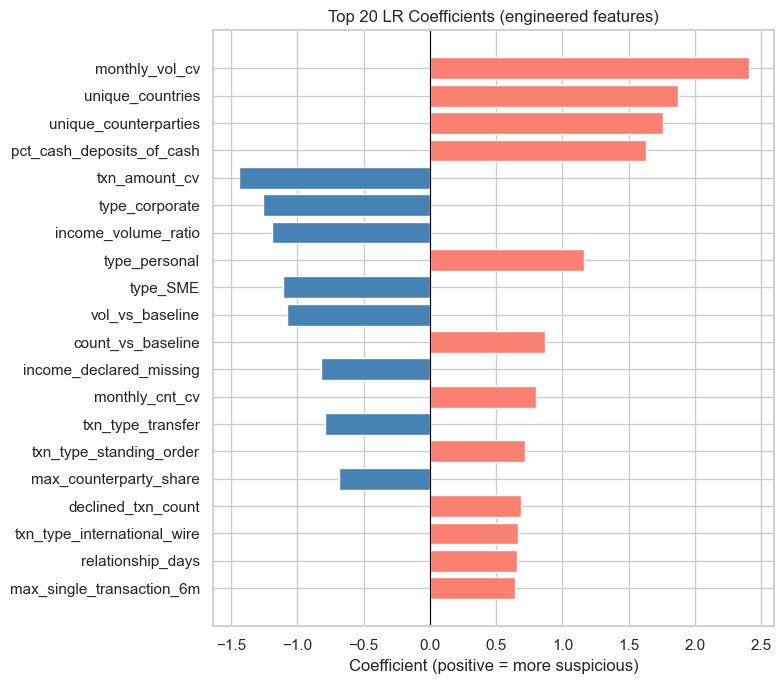

In [5]:
coef_df = pd.DataFrame({
    'feature': feature_cols,
    'coefficient': lr.coef_[0]
}).sort_values('coefficient', key=abs, ascending=False).head(20)

fig, ax = plt.subplots(figsize=(8, 7))
colors = ['salmon' if c > 0 else 'steelblue' for c in coef_df['coefficient']]
ax.barh(coef_df['feature'], coef_df['coefficient'], color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Top 20 LR Coefficients (engineered features)')
ax.set_xlabel('Coefficient (positive = more suspicious)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

---
## 3. Model 2 Ă˘â‚¬â€ť Gradient Boosting

Same hyperparameters as the baseline: shallow trees (`max_depth=3`), `n_estimators=100`, 
`learning_rate=0.05`, `subsample=0.8`. 
With 64 features vs 18 in the baseline, gradient boosting has more combinations to explore Ă˘â‚¬â€ť 
if the engineered features carry real signal, this model should show the largest improvement.

In [6]:
sample_weight = np.where(y_train == 1,
    len(y_train) / (2 * y_train.sum()),
    len(y_train) / (2 * (len(y_train) - y_train.sum()))
)

gb = GradientBoostingClassifier(
    n_estimators=100, max_depth=3, learning_rate=0.05,
    subsample=0.8, min_samples_leaf=5, random_state=42
)
gb.fit(X_train, y_train, sample_weight=sample_weight)

gb_val_proba   = gb.predict_proba(X_val)[:, 1]
gb_train_proba = gb.predict_proba(X_train)[:, 1]
gb_auc         = roc_auc_score(y_val, gb_val_proba)
gb_prauc       = average_precision_score(y_val, gb_val_proba)
gb_train_auc   = roc_auc_score(y_train, gb_train_proba)

print(f'Gradient Boosting   — Train AUC: {gb_train_auc:.4f}  Val AUC-ROC: {gb_auc:.4f}  PR-AUC: {gb_prauc:.4f}')
print(f'                      Train-Val gap: {gb_train_auc - gb_auc:+.4f}')

Gradient Boosting   — Train AUC: 1.0000  Val AUC-ROC: 0.8450  PR-AUC: 0.3727
                      Train-Val gap: +0.1550


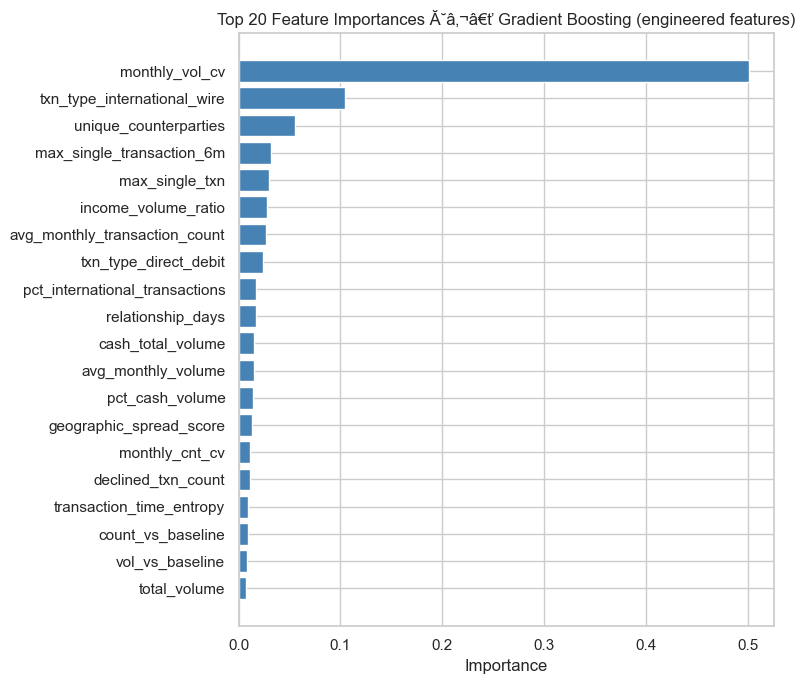

In [7]:
imp_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': gb.feature_importances_
}).sort_values('importance', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(imp_df['feature'], imp_df['importance'], color='steelblue', edgecolor='white')
ax.set_title('Top 20 Feature Importances Ă˘â‚¬â€ť Gradient Boosting (engineered features)')
ax.set_xlabel('Importance')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

---
## 4. Model 3 — Random Forest

**Why:** Random forest builds many shallow decision trees on bootstrapped subsets of the data and averages their predictions. This makes it naturally resistant to overfitting on small datasets — each tree sees a different random subset of training examples and features, so no single noisy positive can dominate.

With only 21 positives, random forest's variance reduction through averaging is a real advantage over a single gradient boosting sequence. Feature importances are identical in interpretation to gradient boosting and easy to explain to compliance analysts. `class_weight='balanced_subsample'` reweights each bootstrap sample independently, which handles imbalance better than a global weight on a dataset this small.

In [8]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=5,
    min_samples_leaf=3,
    max_features='sqrt',
    class_weight='balanced_subsample',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

rf_val_proba  = rf.predict_proba(X_val)[:, 1]
rf_train_proba = rf.predict_proba(X_train)[:, 1]
rf_auc        = roc_auc_score(y_val, rf_val_proba)
rf_prauc      = average_precision_score(y_val, rf_val_proba)
rf_train_auc  = roc_auc_score(y_train, rf_train_proba)

print(f'Random Forest — Train AUC: {rf_train_auc:.4f}  Val AUC-ROC: {rf_auc:.4f}  PR-AUC: {rf_prauc:.4f}')
print(f'               Train-Val gap: {rf_train_auc - rf_auc:+.4f}')

Random Forest — Train AUC: 1.0000  Val AUC-ROC: 0.8485  PR-AUC: 0.4071
               Train-Val gap: +0.1515


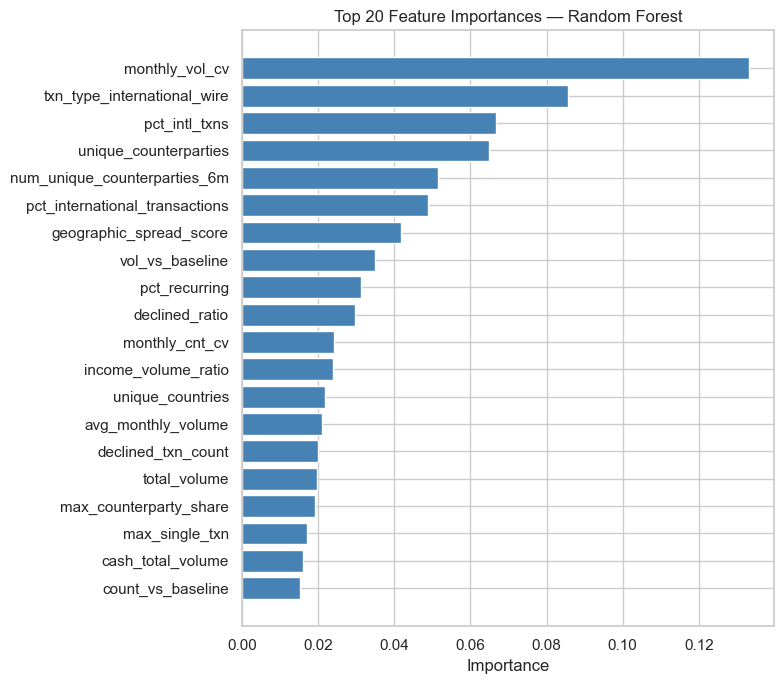

In [9]:
rf_imp = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(rf_imp['feature'], rf_imp['importance'], color='steelblue', edgecolor='white')
ax.set_title('Top 20 Feature Importances — Random Forest')
ax.set_xlabel('Importance')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

---
## 5. Model 4 — XGBoost

**Why:** XGBoost is a faster, more regularised implementation of gradient boosting. Key differences from sklearn's GradientBoostingClassifier:

- `scale_pos_weight` directly tells the model the ratio of negative to positive examples, handling imbalance more explicitly than sample weighting
- `reg_alpha` (L1) and `reg_lambda` (L2) add feature-level regularisation, shrinking unimportant features toward zero — useful with 64 features and 21 positives
- Native SHAP support for per-prediction explanations, which we will use in the app

`scale_pos_weight` is set to the ratio of clean to suspicious examples in the training set.

In [10]:
from xgboost import XGBClassifier

scale_pos = int((y_train == 0).sum() / (y_train == 1).sum())
print(f'scale_pos_weight: {scale_pos} ({(y_train==0).sum()} clean / {(y_train==1).sum()} suspicious)')

xgb = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    eval_metric='auc',
    verbosity=0
)
xgb.fit(X_train, y_train)

xgb_val_proba   = xgb.predict_proba(X_val)[:, 1]
xgb_train_proba = xgb.predict_proba(X_train)[:, 1]
xgb_auc         = roc_auc_score(y_val, xgb_val_proba)
xgb_prauc       = average_precision_score(y_val, xgb_val_proba)
xgb_train_auc   = roc_auc_score(y_train, xgb_train_proba)

print(f'XGBoost       — Train AUC: {xgb_train_auc:.4f}  Val AUC-ROC: {xgb_auc:.4f}  PR-AUC: {xgb_prauc:.4f}')
print(f'               Train-Val gap: {xgb_train_auc - xgb_auc:+.4f}')

scale_pos_weight: 22 (479 clean / 21 suspicious)
XGBoost       — Train AUC: 1.0000  Val AUC-ROC: 0.8732  PR-AUC: 0.5557
               Train-Val gap: +0.1268


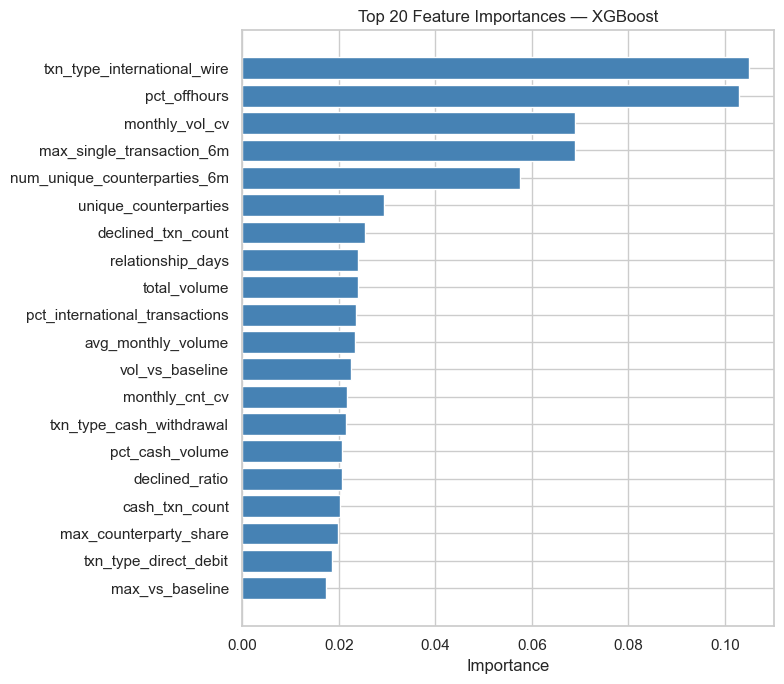

In [11]:
xgb_imp = pd.DataFrame({
    'feature': feature_cols,
    'importance': xgb.feature_importances_
}).sort_values('importance', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(xgb_imp['feature'], xgb_imp['importance'], color='steelblue', edgecolor='white')
ax.set_title('Top 20 Feature Importances — XGBoost')
ax.set_xlabel('Importance')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

---
## 4. Overfitting Check

**Why this matters:** We have 21 positive training examples and many features. 
A model can easily memorise the training positives without learning generalisable patterns. 
The symptom is a large gap between train and val AUC-ROC.

**Train vs val AUC-ROC:** If train >> val, the model has overfit. 
A gap of more than ~0.10 on a dataset this small is worth investigating.

**Stratified K-Fold cross-validation:** Instead of relying on a single train/val split, 
we run 5-fold CV on the training data only. With 21 positives across 5 folds, 
each fold has ~4 positives â€” the scores will have high variance, but the mean and std 
tell us whether performance is consistent or lucky. A high std means the model is 
sensitive to which specific customers end up in each fold.

In [12]:
print('Train vs Val AUC-ROC gap:')
for name, t, v in [
    ('Logistic Regression', lr_train_auc,  lr_auc),
    ('Gradient Boosting  ', gb_train_auc,  gb_auc),
    ('Random Forest      ', rf_train_auc,  rf_auc),
    ('XGBoost            ', xgb_train_auc, xgb_auc),
]:
    print(f'  {name}  train={t:.4f}  val={v:.4f}  gap={t-v:+.4f}')
print()
print('Rule of thumb: gap > 0.10 suggests overfitting.')

Train vs Val AUC-ROC gap:
  Logistic Regression  train=0.9970  val=0.8464  gap=+0.1506
  Gradient Boosting    train=1.0000  val=0.8450  gap=+0.1550
  Random Forest        train=1.0000  val=0.8485  gap=+0.1515
  XGBoost              train=1.0000  val=0.8732  gap=+0.1268

Rule of thumb: gap > 0.10 suggests overfitting.


In [13]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lr_cv_scores = cross_val_score(
    LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    X_train_s, y_train, cv=cv, scoring='roc_auc'
)

gb_cv_scores = cross_val_score(
    GradientBoostingClassifier(
        n_estimators=100, max_depth=3, learning_rate=0.05,
        subsample=0.8, min_samples_leaf=5, random_state=42
    ),
    X_train, y_train, cv=cv, scoring='roc_auc'
)

rf_cv_scores = cross_val_score(
    RandomForestClassifier(
        n_estimators=500, max_depth=5, min_samples_leaf=3,
        max_features='sqrt', class_weight='balanced_subsample',
        random_state=42, n_jobs=-1
    ),
    X_train, y_train, cv=cv, scoring='roc_auc'
)

xgb_cv_scores = cross_val_score(
    XGBClassifier(
        n_estimators=100, max_depth=3, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=scale_pos,
        reg_alpha=0.1, reg_lambda=1.0,
        random_state=42, eval_metric='auc', verbosity=0
    ),
    X_train, y_train, cv=cv, scoring='roc_auc'
)

print('5-Fold Stratified CV on train split (AUC-ROC):')
for name, scores in [
    ('Logistic Regression', lr_cv_scores),
    ('Gradient Boosting  ', gb_cv_scores),
    ('Random Forest      ', rf_cv_scores),
    ('XGBoost            ', xgb_cv_scores),
]:
    print(f'  {name}  mean={scores.mean():.4f}  std={scores.std():.4f}  folds={[round(s,3) for s in scores]}')

5-Fold Stratified CV on train split (AUC-ROC):
  Logistic Regression  mean=0.9078  std=0.0486  folds=[0.971, 0.896, 0.953, 0.839, 0.88]
  Gradient Boosting    mean=0.9385  std=0.0361  folds=[0.977, 0.932, 0.982, 0.888, 0.914]
  Random Forest        mean=0.9341  std=0.0482  folds=[0.992, 0.927, 0.982, 0.862, 0.907]
  XGBoost              mean=0.9339  std=0.0447  folds=[0.99, 0.904, 0.987, 0.901, 0.888]


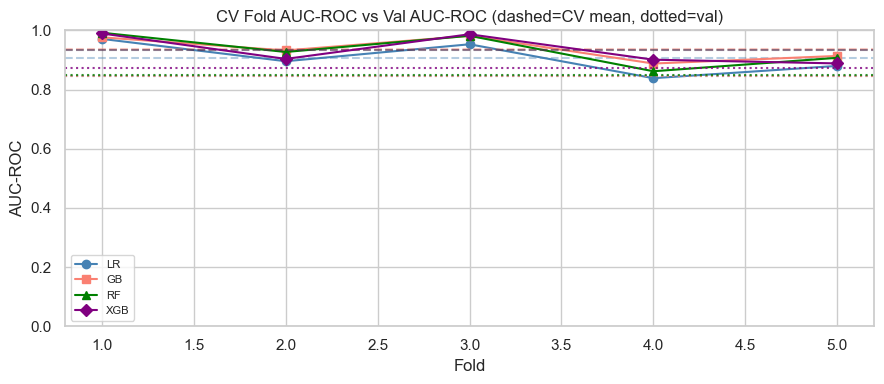

In [14]:
fig, ax = plt.subplots(figsize=(9, 4))
x = range(1, 6)
for name, scores, val_score, color, marker in [
    ('LR',  lr_cv_scores,  lr_auc,  'steelblue', 'o'),
    ('GB',  gb_cv_scores,  gb_auc,  'salmon',    's'),
    ('RF',  rf_cv_scores,  rf_auc,  'green',     '^'),
    ('XGB', xgb_cv_scores, xgb_auc, 'purple',    'D'),
]:
    ax.plot(x, scores, marker=marker, linestyle='-', color=color, label=name)
    ax.axhline(scores.mean(), color=color, linestyle='--', alpha=0.4)
    ax.axhline(val_score,     color=color, linestyle=':',  alpha=0.8)

ax.set_title('CV Fold AUC-ROC vs Val AUC-ROC (dashed=CV mean, dotted=val)')
ax.set_xlabel('Fold')
ax.set_ylabel('AUC-ROC')
ax.set_ylim(0, 1)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

---
## 4. Compare: Baseline vs Engineered Features

Paste in the baseline scores from `03_modeling.ipynb` to see the delta directly. 
The PR curve matters more than ROC given the 4.5% class imbalance.

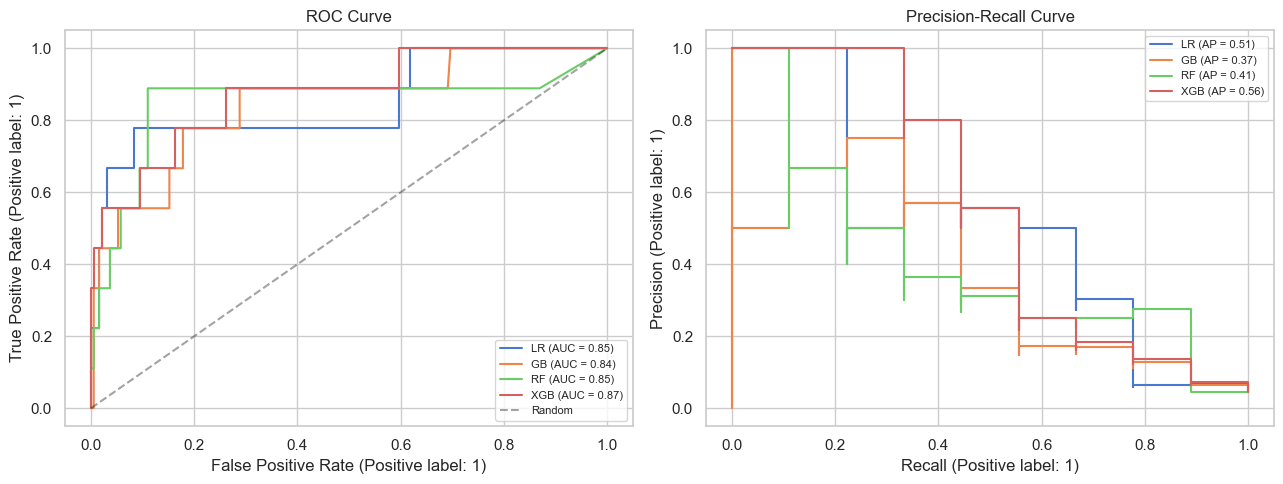

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for name, proba, color in [
    ('LR',  lr_val_proba,  'steelblue'),
    ('GB',  gb_val_proba,  'salmon'),
    ('RF',  rf_val_proba,  'green'),
    ('XGB', xgb_val_proba, 'purple'),
]:
    RocCurveDisplay.from_predictions(y_val, proba, name=name, ax=axes[0])
    PrecisionRecallDisplay.from_predictions(y_val, proba, name=name, ax=axes[1])

axes[0].plot([0,1],[0,1],'k--',alpha=0.4,label='Random')
axes[0].set_title('ROC Curve')
axes[0].legend(fontsize=8)
axes[1].set_title('Precision-Recall Curve')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

In [16]:
print('=' * 60)
print('MODEL SUMMARY')
print('=' * 60)
print(f'{"Model":<30} {"Train AUC":>10} {"Val AUC":>10} {"PR-AUC":>8} {"Gap":>8}')
print('-' * 60)
for name, t_auc, v_auc, prauc in [
    ('Logistic Regression',  lr_train_auc,  lr_auc,  lr_prauc),
    ('Gradient Boosting',    gb_train_auc,  gb_auc,  gb_prauc),
    ('Random Forest',        rf_train_auc,  rf_auc,  rf_prauc),
    ('XGBoost',              xgb_train_auc, xgb_auc, xgb_prauc),
]:
    gap = t_auc - v_auc
    print(f'{name:<30} {t_auc:>10.4f} {v_auc:>10.4f} {prauc:>8.4f} {gap:>+8.4f}')
print('=' * 60)
print('Gap > 0.10 suggests overfitting.')

MODEL SUMMARY
Model                           Train AUC    Val AUC   PR-AUC      Gap
------------------------------------------------------------
Logistic Regression                0.9970     0.8464   0.5075  +0.1506
Gradient Boosting                  1.0000     0.8450   0.3727  +0.1550
Random Forest                      1.0000     0.8485   0.4071  +0.1515
XGBoost                            1.0000     0.8732   0.5557  +0.1268
Gap > 0.10 suggests overfitting.


---
## 5. Generate Submission File

Once we are satisfied with val performance, retrain the best model on train+val combined 
and generate `predictions.csv` for the 500 organiser test customers.

**Important:** only run this cell when we have decided on the final model. 
Retraining on more data (train+val = 700 customers, 30 suspicious) should improve generalisation.

In [17]:
# Retrain best model on train + val combined
train_val = df[df['split'].isin(['train', 'val'])].copy()
test      = df[df['split'] == 'test'].copy()

X_trainval = train_val[feature_cols]
y_trainval = train_val['suspicious_activity_confirmed'].astype(int)

X_test = test[feature_cols]

sw_trainval = np.where(y_trainval == 1,
    len(y_trainval) / (2 * y_trainval.sum()),
    len(y_trainval) / (2 * (len(y_trainval) - y_trainval.sum()))
)

final_model = GradientBoostingClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    min_samples_leaf=5,
    random_state=42
)
final_model.fit(X_trainval, y_trainval, sample_weight=sw_trainval)

test_proba = final_model.predict_proba(X_test)[:, 1]

submission = pd.DataFrame({
    'customer_id': test['customer_id'].values,
    'predicted_probability': test_proba
})

submission.to_csv(OUT + 'predictions.csv', index=False)

print(f'Saved predictions.csv Ă˘â‚¬â€ť {len(submission)} rows')
print(submission['predicted_probability'].describe().round(4))

Saved predictions.csv Ă˘â‚¬â€ť 500 rows
count    500.0000
mean       0.0718
std        0.1425
min        0.0041
25%        0.0107
50%        0.0168
75%        0.0454
max        0.9320
Name: predicted_probability, dtype: float64
